# Lightning Run Analysis (CLI Workflow)

Analyzes training results produced by `closure-train fit`.

`RunLoader` reconstructs the model, data, and test dataset from a
Lightning `version_*` directory, and provides one-liner access to
training history, evaluation metrics, and visualization.

## 1) CLI commands (for reference)

```bash
closure-train fit  --config configs/legacy_harris_4lrs_es500.yaml --trainer.devices=1 --trainer.strategy=auto    --data.num_workers=2    --trainer.logger.init_args.name=CNN --trainer.logger.init_args.version=run_2 --model.network.init_args.channels='[10,256,128,64,6]'   --model.network.init_args.kernels='[5,5,3,3]'   --model.network.init_args.activations='[ReLU,ReLU,SiLU,null]'   --model.network.init_args.batch_norms='[true,true,true,false]'
```
etc...

## 2) Setup &amp; load run

In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from closure import RunLoader

PROJECT_ROOT = Path('/dodrio/scratch/projects/2026_018/george/closure/')
os.chdir(PROJECT_ROOT)

LOG_ROOT = PROJECT_ROOT / 'models/Lightning/Harris/Le/CNN'

# Pick the latest version directory
versions = sorted([p for p in LOG_ROOT.glob('run*') if p.is_dir()])
if not versions:
    raise RuntimeError('No run_* folders found. Run training first.')
latest = versions[-1]
print('Loading:', latest)

run = RunLoader.from_version_dir(latest)
run

Loading: /dodrio/scratch/projects/2026_018/george/closure/models/Lightning/Harris/Le/CNN/run_3


features: 100%|██████████| 3/3 [00:09<00:00,  3.06s/file]
Output shape (3, 10, 512, 150, 1) has more than 4 dimensions, we try fixing by removing single-dimensional entries
Output shape after fixing (3, 10, 512, 150)
targets: 100%|██████████| 3/3 [00:00<00:00,  8.66file/s]
Output shape (3, 6, 512, 150, 1) has more than 4 dimensions, we try fixing by removing single-dimensional entries
Output shape after fixing (3, 6, 512, 150)


RunLoader(run_3, targets=['Pxx_e', 'Pyy_e', 'Pzz_e', 'Pxy_e', 'Pxz_e', 'Pyz_e'], n_test_samples=3, model=ClosureLitModule)

In [2]:
run.datamodule.test_dataset.features.shape, run.datamodule.test_dataset.targets.shape

(torch.Size([3, 10, 512, 150]), torch.Size([3, 6, 512, 150]))

In [3]:
versions

[PosixPath('/dodrio/scratch/projects/2026_018/george/closure/models/Lightning/Harris/Le/CNN/run_1'),
 PosixPath('/dodrio/scratch/projects/2026_018/george/closure/models/Lightning/Harris/Le/CNN/run_1_2gpu'),
 PosixPath('/dodrio/scratch/projects/2026_018/george/closure/models/Lightning/Harris/Le/CNN/run_1_2n2g'),
 PosixPath('/dodrio/scratch/projects/2026_018/george/closure/models/Lightning/Harris/Le/CNN/run_2'),
 PosixPath('/dodrio/scratch/projects/2026_018/george/closure/models/Lightning/Harris/Le/CNN/run_3')]

## 3) Inspect runtime config

Access the full config dict via `run.config`.

In [4]:
for section in ('trainer', 'data'):
    print(f'\n[{section}]')
    for k, v in run.config.get(section, {}).items():
        if not isinstance(v, (dict, list)):
            print(f'  {k}: {v}')

print('\n[model.network]')
net_cfg = run.config.get('model', {}).get('network', {})
print(f'  class_path: {net_cfg.get("class_path")}')
print(f'  init_args:  {net_cfg.get("init_args", {})}')


[trainer]
  accelerator: auto
  strategy: auto
  devices: 1
  num_nodes: 1
  precision: 32-true
  fast_dev_run: False
  max_epochs: 500
  min_epochs: None
  max_steps: -1
  min_steps: None
  max_time: None
  limit_train_batches: None
  limit_val_batches: None
  limit_test_batches: None
  limit_predict_batches: None
  overfit_batches: 0.0
  val_check_interval: None
  check_val_every_n_epoch: 1
  num_sanity_val_steps: None
  log_every_n_steps: None
  enable_checkpointing: None
  enable_progress_bar: None
  enable_model_summary: None
  accumulate_grad_batches: 1
  gradient_clip_val: None
  gradient_clip_algorithm: None
  deterministic: None
  benchmark: None
  inference_mode: True
  use_distributed_sampler: True
  profiler: None
  detect_anomaly: False
  barebones: False
  plugins: None
  sync_batchnorm: False
  reload_dataloaders_every_n_epochs: 0
  default_root_dir: ./models/Lightning/Harris/Le

[data]
  data_folder: ecsim/Harris/Le/
  norm_folder: ./models/Lightning/Harris/Le
  train_

## 4) Training history &amp; loss curves

,epoch,train_loss,val_loss,lr-Adam
492,492.0,0.010820,0.008341,0.00001
493,493.0,0.011605,0.008442,0.00001
494,494.0,0.011165,0.008160,0.00001
495,495.0,0.010879,0.008468,0.00001
496,496.0,0.011479,0.008551,0.00001
497,497.0,0.011431,0.008726,0.00001
498,498.0,0.011329,0.008459,0.00001
499,499.0,0.010795,0.008569,0.00001


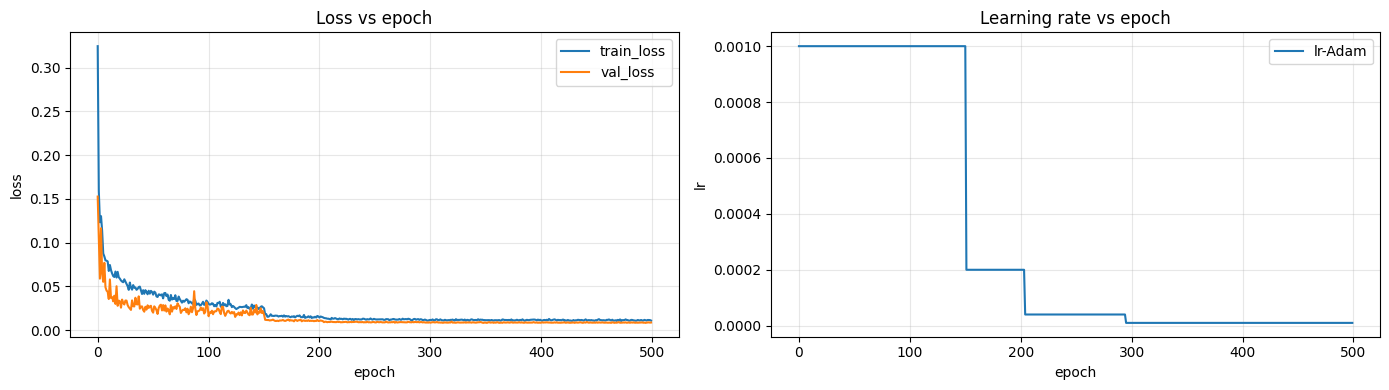

In [5]:
display(run.history().tail(8))
run.plot_history()

## 5) Best &amp; final epoch

In [6]:
run.best_epoch()

{'best_epoch': 463,
 'best_val_loss': 0.0081386445090174,
 'final_epoch': 499,
 'final_train_loss': 0.0107947550714015,
 'final_val_loss': 0.0085691669955849}

In [7]:
RunLoader.compare_versions(LOG_ROOT)

""


## 6) Compare multiple Lightning versions

,run,best_val_loss,best_epoch
0,run_1,0.008120,445
1,run_1_2gpu,0.010311,335
2,run_1_2n2g,0.005276,427
3,run_2,0.034314,224
4,run_3,0.008139,463


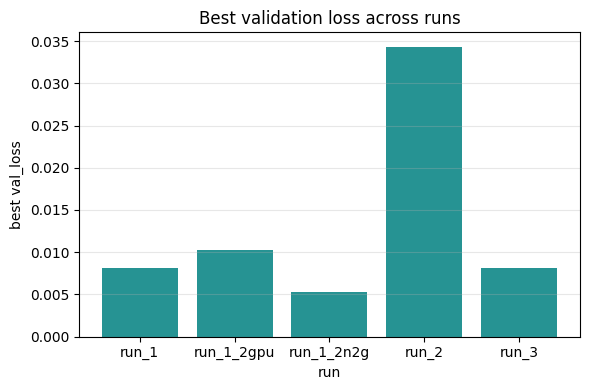

In [8]:
import pandas as pd

# Scan for all run_* directories and compare them
run_dirs = sorted([p for p in LOG_ROOT.glob('run_*') if p.is_dir()])
rows = []
for run_dir in run_dirs:
    csv_path = run_dir / 'metrics.csv'
    if not csv_path.exists():
        continue
    df = pd.read_csv(csv_path)
    valid = df.dropna(subset=['val_loss'])
    if not valid.empty:
        best_idx = valid['val_loss'].idxmin()
        rows.append({
            'run': run_dir.name,
            'best_val_loss': float(valid.loc[best_idx, 'val_loss']),
            'best_epoch': int(valid.loc[best_idx, 'epoch']) if 'epoch' in valid.columns else None,
        })

compare_df = pd.DataFrame(rows) if rows else pd.DataFrame()
display(compare_df)

if compare_df.empty:
    print(f"No runs found with metrics.csv in {LOG_ROOT}")
else:
    plt.figure(figsize=(6, 4))
    plt.bar(compare_df['run'], compare_df['best_val_loss'], color='teal', alpha=0.85)
    plt.title('Best validation loss across runs')
    plt.xlabel('run'); plt.ylabel('best val_loss')
    plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

## 7) Per-channel regression metrics

,channel_index,channel,mse,rmse,mae,r2,pearson_r,mean_abs_ground_truth,nrmse
1,1,Pyy_e,0.005966,0.077242,0.046626,0.995307,0.998095,0.945236,0.081717
2,2,Pzz_e,0.005900,0.076809,0.045831,0.994647,0.997691,0.884642,0.086825
0,0,Pxx_e,0.008201,0.090558,0.054060,0.992433,0.996912,0.865802,0.104595
5,5,Pyz_e,0.019623,0.140082,0.074098,0.985853,0.993447,0.424278,0.330166
4,4,Pxz_e,0.013893,0.117868,0.075595,0.985489,0.992749,0.554017,0.212753
3,3,Pxy_e,0.037439,0.193491,0.114218,0.971729,0.985890,0.570792,0.338986


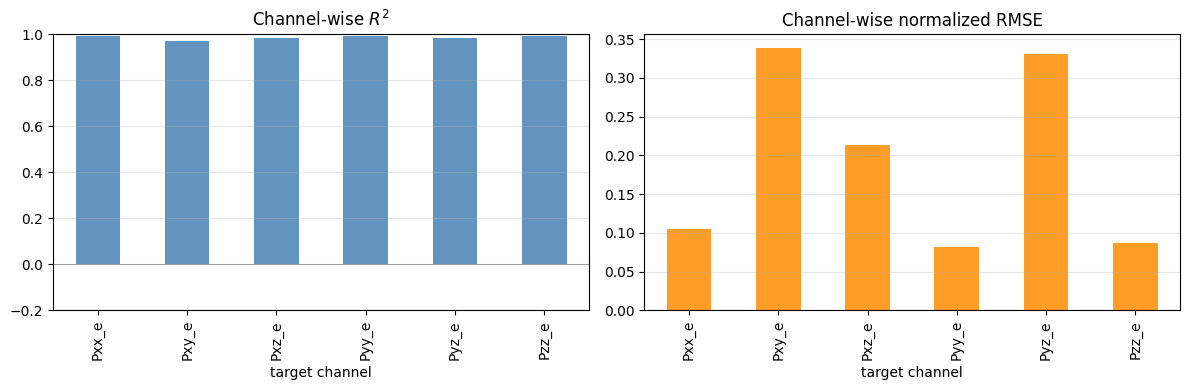

In [9]:
metrics_df = run.metrics()
display(metrics_df.sort_values('r2', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ms = metrics_df.set_index('channel').sort_index()

ms['r2'].plot.bar(ax=axes[0], color='steelblue', alpha=0.85)
axes[0].set_title('Channel-wise $R^2$')
axes[0].set_ylim(-0.2, 1.0)
axes[0].axhline(0, color='grey', linewidth=0.5)
axes[0].grid(axis='y', alpha=0.3)

ms['nrmse'].plot.bar(ax=axes[1], color='darkorange', alpha=0.85)
axes[1].set_title('Channel-wise normalized RMSE')
axes[1].grid(axis='y', alpha=0.3)

for ax in axes:
    ax.set_xlabel('target channel')
plt.tight_layout(); plt.show()

## 8) Predicted vs ground-truth images

Diagonal pressures (e.g. $P_{xx}$) use a sequential colormap.
Off-diagonal pressures ($P_{xy}$, etc.) are signed → diverging colormap.

invfunc = <ufunc 'exp'>


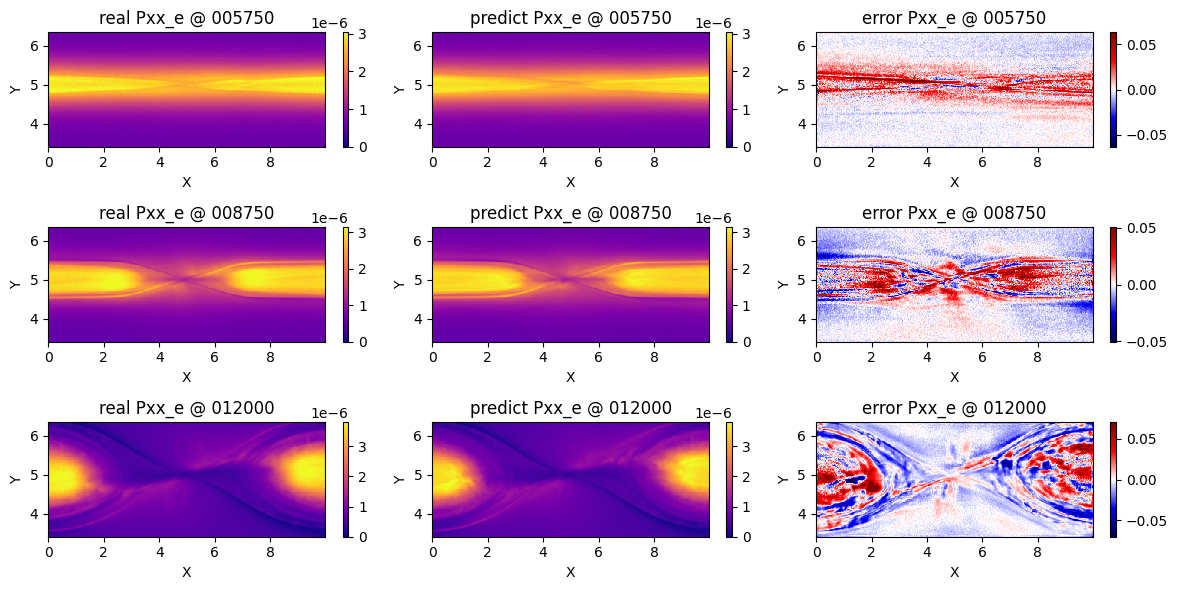

In [10]:
# Diagonal pressure
run.plot('Pxx_e', robust_quantile=0.995, error_mode='relative',
         signed_target_names=['Pxy_e', 'Pxz_e', 'Pyz_e'])

invfunc = <ufunc 'sinh'>


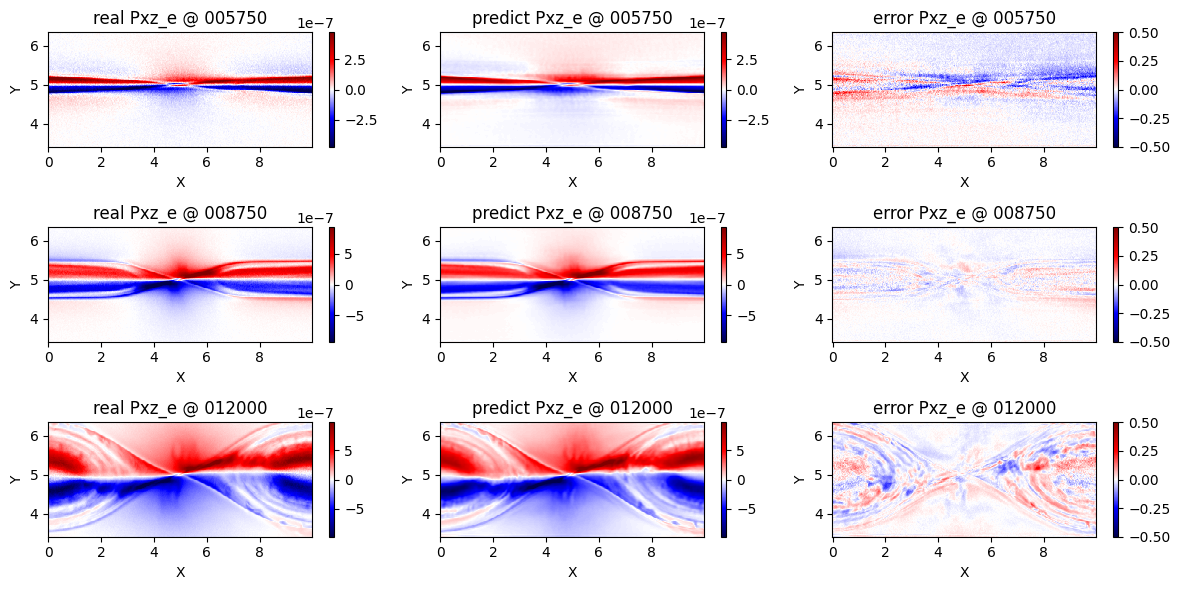

In [11]:
# Off-diagonal pressure (signed → diverging colormap)
offdiag = 'Pxz_e' if 'Pxz_e' in run.dataset.request_targets else run.dataset.request_targets[0]
run.plot(offdiag, robust_quantile=0.995, error_mode='symmetric_percent',
         error_limit=0.5, signed_target_names=['Pxy_e', 'Pxz_e', 'Pyz_e'])

Plotting off-diagonal channel: Pxy_e
invfunc = <ufunc 'sinh'>


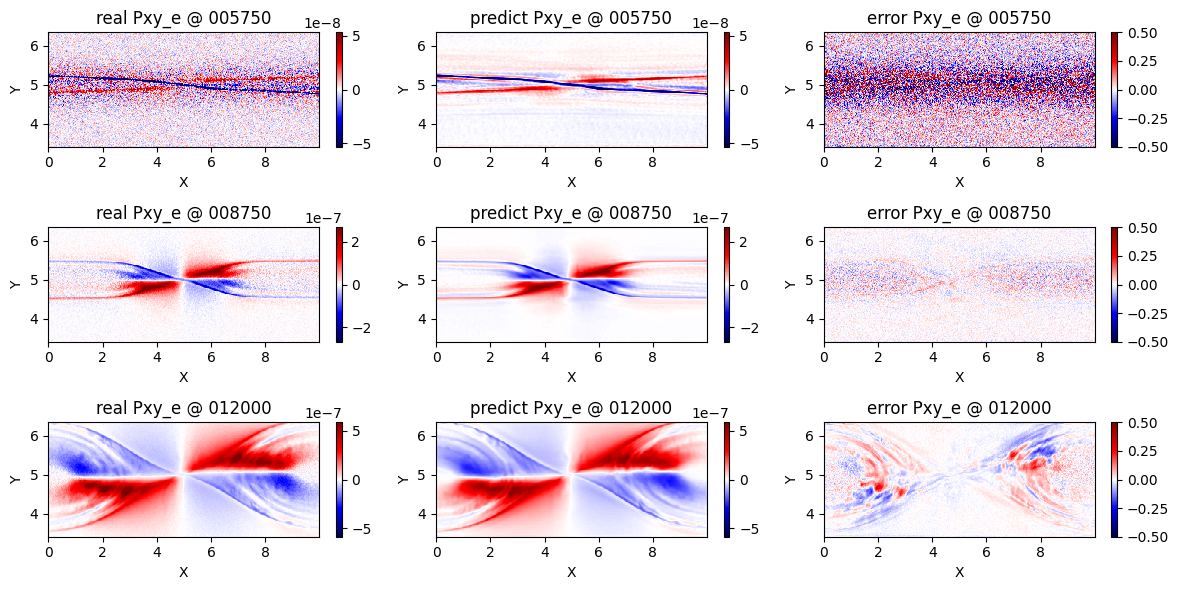

In [12]:
# Off-diagonal pressure (signed → diverging colormap)
offdiag = 'Pxy_e' if 'Pxy_e' in run.dataset.request_targets else run.dataset.request_targets[0]
print(f"Plotting off-diagonal channel: {offdiag}")
run.plot(offdiag, robust_quantile=0.995, error_mode='symmetric_percent',
         error_limit=0.5, signed_target_names=['Pxy_e', 'Pxz_e', 'Pyz_e'])

## 9) Predicted vs true scatter

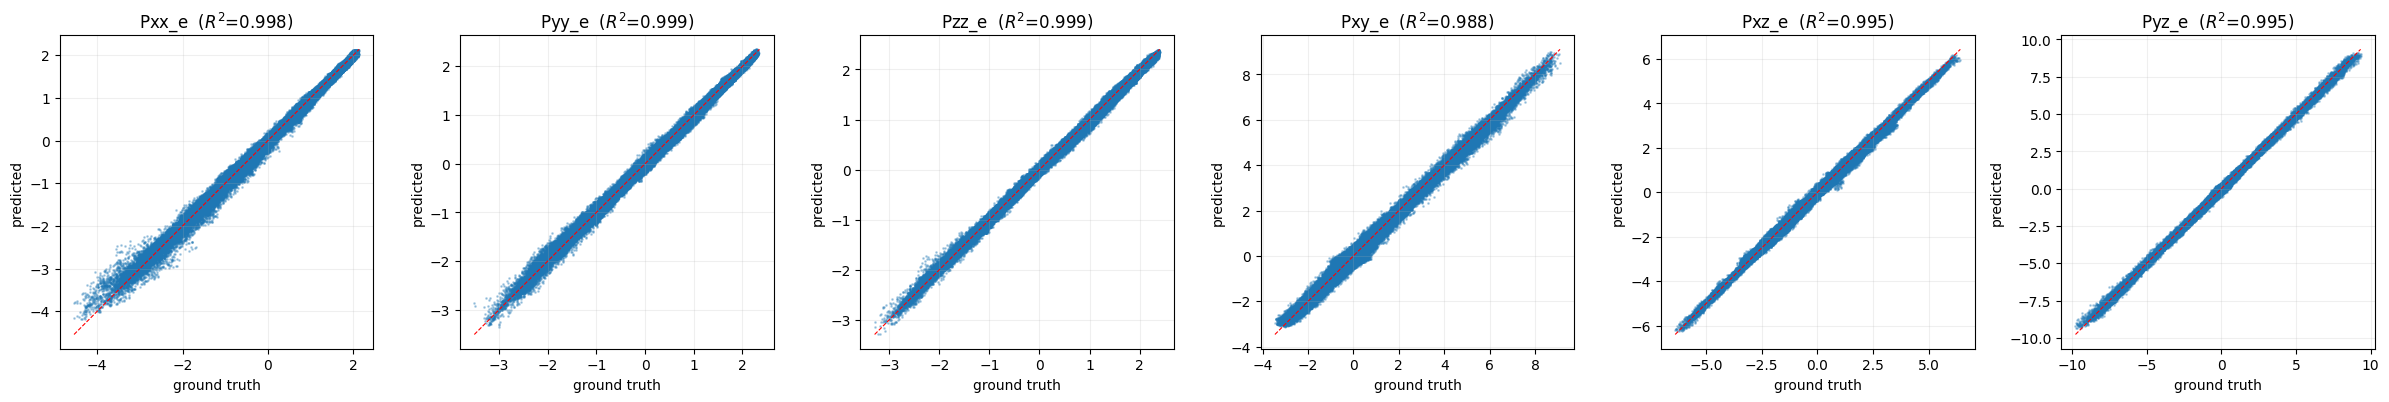

In [13]:
gt, pred = run.predict()
channels = run.dataset.request_targets
n_ch = len(channels)

fig, axes = plt.subplots(1, n_ch, figsize=(4 * n_ch, 4), squeeze=False)
for idx, ch_name in enumerate(channels):
    ax = axes[0, idx]
    y, yhat = gt[:, idx].ravel(), pred[:, idx].ravel()
    ax.scatter(y, yhat, s=1, alpha=0.3)
    lims = [min(y.min(), yhat.min()), max(y.max(), yhat.max())]
    ax.plot(lims, lims, 'r--', linewidth=0.8)
    ax.set_xlabel('ground truth'); ax.set_ylabel('predicted')
    r2 = metrics_df.loc[metrics_df.channel == ch_name, 'r2'].values[0]
    ax.set_title(f'{ch_name}  ($R^2$={r2:.3f})')
    ax.set_aspect('equal', adjustable='box'); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()